In [20]:
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace, HuggingFaceEmbeddings
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated, Literal
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, RemoveMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from tavily import TavilyClient
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import interrupt, Command
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore
from langchain_core.messages import trim_messages
import uuid

In [21]:
import os
import requests
from dotenv import load_dotenv
load_dotenv()

True

In [22]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-72B-Instruct",
    task="text-generation",
)

# Step 2: Chat wrapper लगाओ
model = ChatHuggingFace(llm=llm)

In [23]:
class schema(TypedDict):
    chat_or_post_dec : str
    messages : Annotated[list[BaseMessage],add_messages]
    linkedin_post_text : str
    score : float 
    iteration : int
    max_iteration : int
    summary : str

In [24]:
class chat_or_post_schema(BaseModel):
    decision : Literal["post_generation","normal_chat"]

chat_or_post_outputparser = PydanticOutputParser(pydantic_object=chat_or_post_schema)
system_prompt = ChatPromptTemplate.from_messages([
    ("system", """
    You are a highly precise routing assistant for a LinkedIn Automation Agent. Your ONLY job is to classify the user's latest message into one of two decisions: "post_generation" or "normal_chat".

    CRITICAL CLASSIFICATION RULES:
    
    1. Select "post_generation" ONLY if:
        - The user is explicitly asking to write, create, generate, draft, rewrite, structure, or improve a LinkedIn post.
        - Example: "Write a post about AI", "make it shorter", "add emojis to this draft".

    2. Select "normal_chat" for EVERYTHING ELSE, including:
        - Greetings, casual talk, small talk, or general queries (e.g., "hi", "hello", "how are you?").
        - Conversation endings or exit intents (e.g., "bye", "goodbye", "exit", "quit", "thank you", "thanks", "done").
        - Acknowledgments, vague confirmations, or casual agreements (e.g., "ok", "okay", "yes", "no", "sure", "fine", "cool").
        - Context-less or empty responses where no post-writing intent is specified.

    Strict Constraints:
    - Return ONLY valid JSON matching the schema. No explanations, no markdown (do NOT wrap in ```json), no conversational filler.
    - If you are even slightly unsure or if the message is ambiguous, ALWAYS default to "normal_chat".

    Examples:
    User: "Write a short LinkedIn post on AI/ML" -> {{"decision": "post_generation"}}
    User: "make the tone professional" -> {{"decision": "post_generation"}}
    User: "bye" -> {{"decision": "normal_chat"}}
    User: "ok" -> {{"decision": "normal_chat"}}
    User: "hello agent" -> {{"decision": "normal_chat"}}
    User: "no thanks" -> {{"decision": "normal_chat"}}

    {format_instructions}
    """),
    ("human", "{query}")   
]).partial(format_instructions=chat_or_post_outputparser.get_format_instructions())
def chat_or_post(state: schema)-> schema:
    question = state['messages'][-1].content
    chain = system_prompt | model | chat_or_post_outputparser
    answer = chain.invoke({'query':question})
    return {'chat_or_post_dec':answer.decision}

In [25]:
client = TavilyClient()
@tool
def Internet_Search(query: str) -> str:
    """
    Search the internet for current, recent, or verifiable information.

    This tool provides up-to-date information from the web and should be used
    whenever the answer may depend on information that changes over time.

    Use this tool when:
    - The user asks about current events, breaking news, or recent developments.
    - The user mentions terms such as "today", "yesterday", "latest", "recent", "currently", or "news".
    - The user asks about sports results, match summaries, rankings, or schedules.
    - The user asks about companies, products, technologies, or public figures that may require fresh information.
    - The user requests fact-checking or verification.
    - The user explicitly asks to search the web, internet, Google, or online sources.

    Do NOT use this tool when:
    - The user is having casual conversation.
    - The answer can be provided from general knowledge without needing current information.
    - The task is creative writing, brainstorming, storytelling, email writing, or LinkedIn post generation that does not require external research.
    - The user is asking for personal opinions or recommendations that do not require web data.

    Guidelines:
    - Prefer using this tool before answering questions about recent events.
    - If search results are found, use them to produce an accurate and factual response.
    - If the search results are insufficient, explain the limitation instead of inventing information.
    - Never fabricate facts when current information is required.

    Args:
        query: A clear and specific search query describing the information to retrieve.

    Returns:
        A concise collection of relevant information gathered from web search results.
    """
    answer = client.search(query=query)

    return "\n\n".join(result.get("content", "") for result in answer.get("results", []))

In [26]:
@tool
def linkedin_post(post_text: str) -> str:
    """
    Publishes a post directly to LinkedIn.

    Use this tool ONLY when user explicitly says:
    'post it', 'publish it', 'push it on linkedin', 'share it on linkedin'.

    Do NOT call this for writing, drafting, or generating posts.

    Args:
        text: Final LinkedIn post content to publish.
    """

    def get_profile_urn():
        token = os.getenv("LINKEDIN_ACCESS_TOKEN")
        response = requests.get(
            "https://api.linkedin.com/v2/userinfo",
            headers={"Authorization": f"Bearer {token}"}
        )
        return response.json().get("sub")

    person_id = get_profile_urn()
    author_urn = f"urn:li:person:{person_id}"
    token = os.getenv("LINKEDIN_ACCESS_TOKEN")

    headers = {
        "Authorization": f"Bearer {token}",
        "Content-Type": "application/json",
        "X-Restli-Protocol-Version": "2.0.0"
    }

    payload = {
        "author": author_urn,
        "lifecycleState": "PUBLISHED",
        "specificContent": {
            "com.linkedin.ugc.ShareContent": {
                "shareCommentary": {"text": post_text},
                "shareMediaCategory": "NONE"
            }
        },
        "visibility": {
            "com.linkedin.ugc.MemberNetworkVisibility": "PUBLIC"
        }
    }

    response = requests.post(
        "https://api.linkedin.com/v2/ugcPosts",
        headers=headers,
        json=payload
    )

    if response.status_code == 201:
        return f"✅ Post successfully published!\n\n📝 Content:\n{post_text}"
    else:
        return f"Error: {response.status_code} - {response.json()}"

In [27]:
tools = [Internet_Search, linkedin_post]
model_bind_tools = model.bind_tools(tools)

In [28]:
def chat(state: schema, config: RunnableConfig, store: BaseStore):
    trimmed = trim_messages(
        state["messages"],
        max_tokens=4000,
        token_counter=model,
        strategy="last",
        include_system=True,
    )

    prompt = ChatPromptTemplate([("system",
                    """You are a LinkedIn post generation assistant.

                    Your job:
                    1. Search for latest info if needed (use search tool)
                    2. Write a high quality LinkedIn post
                    3. If user said "post it", "publish it", "post now" — use linkedin_post tool to publish
                    4. If user only said "write" or "create" — just show the post, ask before publishing

                    IMPORTANT: 
                    - Check user's original message carefully
                    - "write and post" = generate + publish in same flow
                    - "write" only = generate and show, wait for approval
                    """),
                    ('human','{message}')])

    chain = prompt | model_bind_tools
    answer = chain.invoke({"message": trimmed})
    return {"messages":[answer]}

In [29]:
def generate_post(state: schema) -> schema:
    trimmed = trim_messages(
        state["messages"],
        max_tokens=4000,
        token_counter=model,
        strategy="last",
        include_system=True,
    )

    system_prompt = f"""
                    You are an expert LinkedIn ghostwriter.

                    Write engaging, human-like LinkedIn posts that are valuable, authentic, and easy to read.

                    Rules:

                    Start with a strong hook.
                    Share a story, insight, lesson, or experience.
                    Use short paragraphs and plenty of whitespace.
                    Focus on actionable value, not motivation.
                    Avoid corporate jargon, buzzwords, and AI-sounding language.
                    Never start with "Excited to share", "Thrilled", or similar phrases.
                    End with a thoughtful question.
                    Add exactly 3 relevant hashtags.

                    If web search results are available, use them naturally to strengthen the post.
                    Your job:
                    1. Search for latest info if needed (use search tool)
                    2. Write a high quality LinkedIn post
                    3. If user said "post it", "publish it", "post now" — use linkedin_post tool to publish
                    4. If user only said "write" or "create" — just show the post, ask before publishing

                    IMPORTANT: 
                    - Check user's original message carefully
                    - "write and post" = generate + publish in same flow
                    - "write" only = generate and show, wait for approval

                    Return only the final LinkedIn post.
                                        """

    prompt = ChatPromptTemplate.from_messages([("system", system_prompt),("human","{query}")])
    chain = prompt | model_bind_tools
    result = chain.invoke({"query": trimmed})

    return {"linkedin_post_text": result.content,"messages":[result]}

In [30]:
class postscoreschema(BaseModel):
    score: float = Field(ge=0.0, le=10.0, description="Based on linkedin post give a score between 0.0 to 10.0")

postscore_parser = PydanticOutputParser(pydantic_object=postscoreschema)

postscore_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a strict LinkedIn content evaluator.

                    Score the given post honestly from 0.0 to 10.0.

                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    SCORE EACH (0.0 to 2.0):
                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    1. HOOK (0-2):
                    0.0 = Starts with I/We/Emoji/cliché
                    1.0 = Interesting, makes reader pause
                    2.0 = Impossible to scroll past

                    2. VALUE (0-2):
                    0.0 = Generic fluff, obvious statements
                    1.0 = One useful insight
                    2.0 = Specific, actionable, data-backed

                    3. STORY (0-2):
                    0.0 = No story, just statements
                    1.0 = Clear story with conflict
                    2.0 = Emotional and memorable

                    4. FORMATTING (0-2):
                    0.0 = Wall of text, emoji overload
                    1.0 = Clean and readable
                    2.0 = Perfect visual flow

                    5. CTA + HASHTAGS (0-2):
                    0.0 = No CTA or hashtag spam
                    1.0 = Clear CTA, 3 hashtags
                    2.0 = Irresistible CTA

                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    DEDUCTIONS:
                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    - "excited/thrilled/honored"  → -0.5
                    - More than 3 hashtags        → -0.5
                    - Starts with emoji           → -0.5
                    - "journey/passion/synergy"   → -0.5
                    - Generic motivational tone   → -0.5

                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    SCORE GUIDE:
                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    0-3   = Terrible
                    3-5   = Poor
                    5-6.5 = Average
                    6.5-8 = Good
                    8-10  = Excellent

                    {format_instructions}"""),
    ("human", "Score this LinkedIn post:\n\n{post}")
]).partial(format_instructions=postscore_parser.get_format_instructions())  


def postscore(state: schema) -> schema:
    post = state['linkedin_post_text']
    chain = postscore_prompt | model | postscore_parser
    result = chain.invoke({"post": post})
    return {"score": result.score}

In [ ]:
def regenerate_post(state : schema)-> schema:
    score = state['score']
    original_post = state['linkedin_post_text']
    iteration = state['iteration']
    prompt = ChatPromptTemplate([
        ('system',"""You are a viral LinkedIn content writer.

                    OUTPUT RULE: Write ONLY the post. No intro, no explanation, no "Sure here's...", no "Note:". Just the post.

                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    STRUCTURE (FOLLOW EXACTLY):
                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    1. HOOK: One powerful line. Creates curiosity or shock.
                    Use: Bold claim / Surprising number / Personal failure / Contrarian truth
                    
                    2. STORY: 3 short paragraphs. Problem → Struggle → Breakthrough.
                    Use specific numbers and dates. Max 2-3 lines per paragraph.

                    3. INSIGHT: One specific "AHA" lesson learned.

                    4. TAKEAWAYS: 3 lines starting with →
                    → Start each with action verb (Do/Stop/Build/Learn)

                    5. CTA: One question ending with 

                    6. HASHTAGS: Exactly 3 (1 broad, 1 niche, 1 trending)

                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    RULES:
                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    Short sentences. They hit harder.
                    White space between paragraphs
                    Max 2 emojis in entire post
                    Specific over generic always
                    Show vulnerability

                    Never start with: I / We / Emoji / "Excited to share"
                    No jargon: leverage, synergy, paradigm, game changer
                    No humble brag
                    No motivational fluff
                    No "journey/passion/crushing it"
                    No more than 3 hashtags
                    No walls of text"""),
        ("human","""Previous Post (Score: {score}/10):{original_post}
                    Please rewrite this post and make it significantly better.""")
                        ])
    chain = prompt | model_bind_tools
    result = chain.invoke({'score':score,'original_post':original_post})
    return {'linkedin_post_text': result.content,'messages':[result],'iteration':iteration + 1,'score': 0.0}

In [32]:
def chat_or_post_decision(state: schema):
    decision = state['chat_or_post_dec']
    if decision == "post_generation":
        return 'generate_post'
    else:
        return 'chat'

In [ ]:
def generate_post_tool_router(state: schema):
    messages = state["messages"]
    last_msg = messages[-1]
    
    if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
        tool_name = last_msg.tool_calls[0]['name']
        if tool_name == 'linkedin_post':
            return 'tools'
        elif tool_name == 'Internet_Search':
            return 'tools'
            
    return 'postscore'

In [ ]:
def chat_tools_router(state):
    if len(state["messages"]) > 8:
        return "store_memory"
    return END

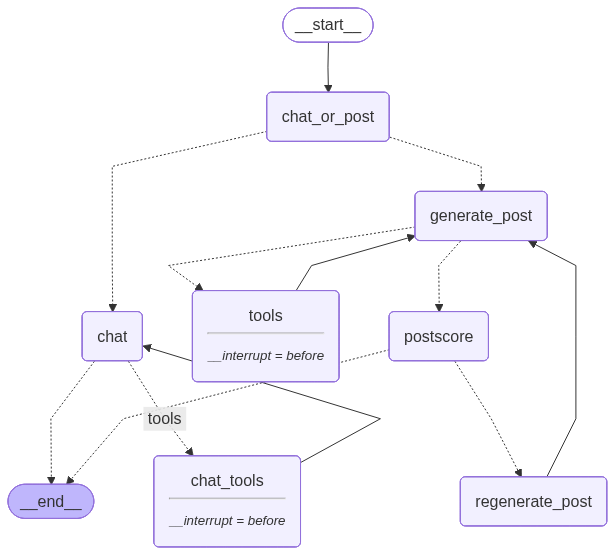

In [50]:
graph = StateGraph(schema)

graph.add_node('chat_or_post', chat_or_post)
graph.add_node('chat', chat)
graph.add_node('chat_tools', ToolNode(tools))  
graph.add_node('tools', ToolNode([Internet_Search, linkedin_post]))
graph.add_node('generate_post', generate_post)
graph.add_node('postscore', postscore)
graph.add_node('regenerate_post', regenerate_post)

graph.add_edge(START, "chat_or_post")
graph.add_conditional_edges('chat_or_post',chat_or_post_decision,{'chat': 'chat','generate_post': 'generate_post'})
graph.add_conditional_edges('chat',tools_condition,{"tools": "chat_tools",END: "__end__"})
graph.add_edge('chat_tools', 'chat')

graph.add_conditional_edges('generate_post',generate_post_tool_router,{'tools': 'tools','postscore': 'postscore'})
graph.add_edge('tools', 'generate_post')
graph.add_conditional_edges("postscore",postscore_router,{"regenerate_post": "regenerate_post",END: "__end__"})
graph.add_edge('regenerate_post', 'generate_post')
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer,interrupt_before=["tools","chat_tools"])
workflow

In [ ]:
config = {"configurable": {"thread_id": "0"}}
while True:
    user = input("You: ")
    print(f"\nYou : {user}")
    if user.lower() in ["bye", "exit"]:
        break
    async for _ in workflow.astream({"messages": [HumanMessage(content=user)],"iteration": 0,"max_iteration": 3,"score": 0.0},config,stream_mode="values"):
        pass
    state = await workflow.aget_state(config)
    while state.next:
        print("\nTool requested — allow karna chahte ho?")
        approval = input("yes/no: ").strip().lower()
        if approval == "yes":
            async for _ in workflow.astream(Command(resume=True), config, stream_mode="values"):
                pass
            state = await workflow.aget_state(config)
        else:
            await workflow.aupdate_state(config,{"messages": [AIMessage(content="Action cancelled by user.")]})
            break
    final = await workflow.aget_state(config)
    msgs = final.values.get("messages", [])
    if msgs:
        print("\nAgent:", msgs[-1].content)


You : generate a two line of linkedin post

Agent: Sure, here's a concise LinkedIn post for you:

---

**Top News of the Day:**

1. Trump administration drops $1.8 billion 'weaponization' fund after Republican backlash.
2. Bennett wins Democratic nomination in New Jersey primary.

What are your thoughts?

#Politics #News #Elections

---

Would you like to post this now?

You : post it on linkedin

⚠️ Tool requested — allow karna chahte ho?

Agent: The post has been successfully published to LinkedIn!

Here's the content of the post:

---

**Top News of the Day:**

1. Trump administration drops $1.8 billion 'weaponization' fund after Republican backlash.
2. Bennett wins Democratic nomination in New Jersey primary.

What are your thoughts?

#Politics #News #Elections

---

You : give me top todays news

⚠️ Tool requested — allow karna chahte ho?

Agent: Here are the top news stories for today:

1. **U.S., Iran Trade Attacks as Iranian Officer Says Renewed War Seems "Inevitable"**:
   - 